In [1]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
import tensorflow as tf

# Load & preprocess
df = pd.read_csv(r'C:\Users\Nicky\churn_prediction\data\healthcare\train_data.csv').copy()
df.drop(['case_id', 'patientid'], axis=1, inplace=True)
df['Bed Grade'] = df['Bed Grade'].fillna(df['Bed Grade'].mode()[0])
df['City_Code_Patient'] = df['City_Code_Patient'].fillna(df['City_Code_Patient'].mode()[0])

le = LabelEncoder()
cat_cols = [col for col in df.select_dtypes(include=['object','str']).columns if col != 'Stay']
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))
df['Stay'] = le.fit_transform(df['Stay'].astype(str))

X = df.drop('Stay', axis=1)
y = df['Stay']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = tf.keras.models.load_model(r'C:\Users\Nicky\churn_prediction\models\deep_learning_model.keras')
dl_pred = model.predict(X_test_scaled).argmax(axis=1)
print("✅ Ready!")

1991/1991 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step
✅ Ready!


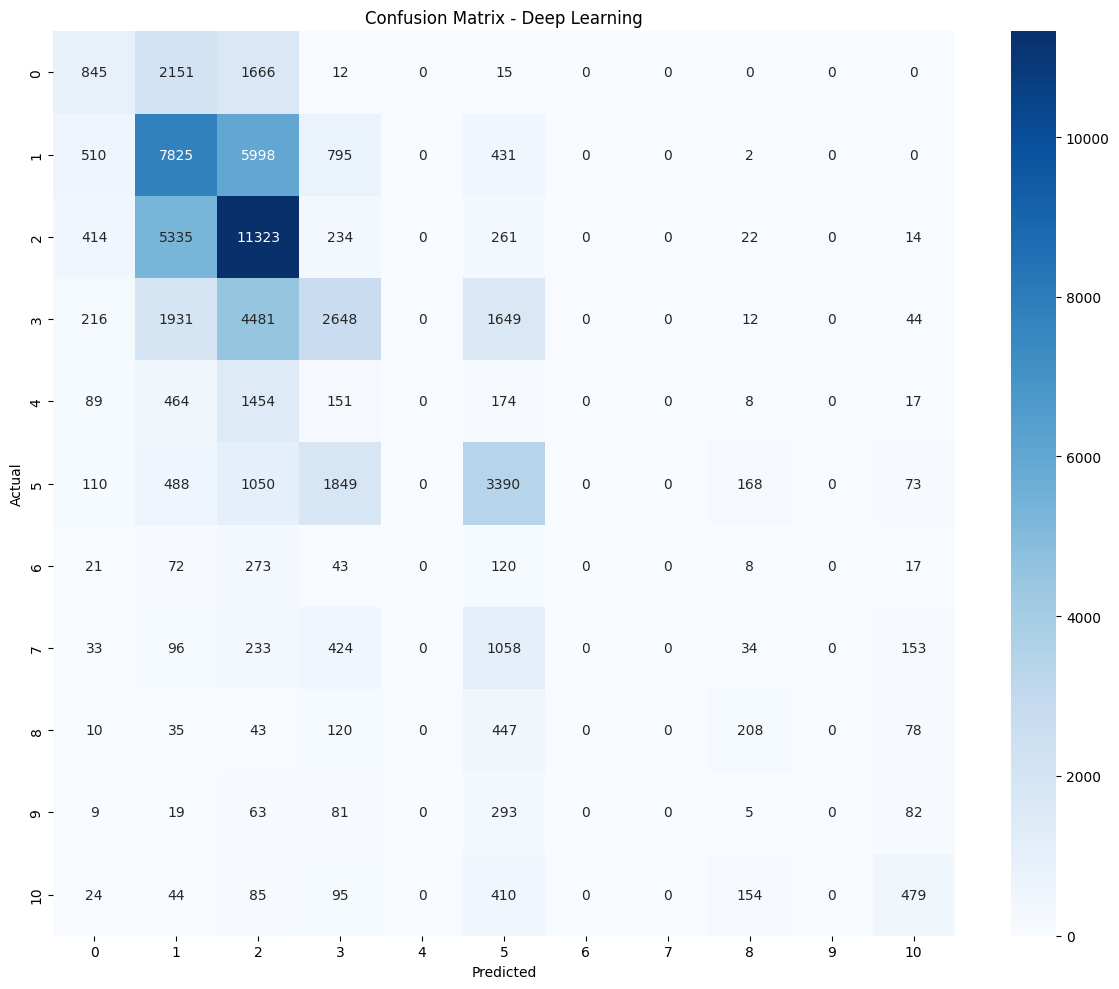

✅ Saved!


In [2]:
cm = confusion_matrix(y_test, dl_pred)
fig, ax = plt.subplots(figsize=(12,10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Confusion Matrix - Deep Learning')
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
plt.tight_layout()
fig.savefig(r'C:\Users\Nicky\churn_prediction\reports\confusion_matrix.png')
plt.show()
print("✅ Saved!")

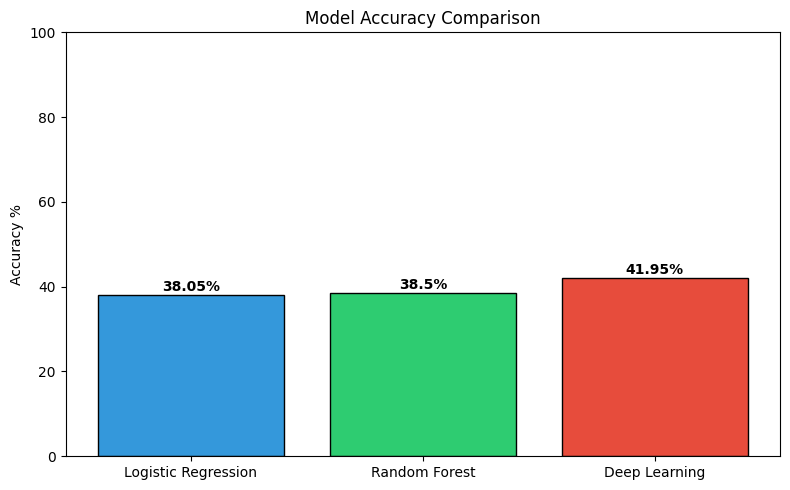

In [3]:
models = ['Logistic Regression', 'Random Forest', 'Deep Learning']
accuracies = [38.05, 38.50, 41.95]

fig, ax = plt.subplots(figsize=(8,5))
bars = ax.bar(models, accuracies, color=['#3498db','#2ecc71','#e74c3c'], edgecolor='black')
ax.set_ylim(0, 100)
ax.set_title('Model Accuracy Comparison')
ax.set_ylabel('Accuracy %')
for bar, acc in zip(bars, accuracies):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            f'{acc}%', ha='center', fontweight='bold')
plt.tight_layout()
fig.savefig(r'C:\Users\Nicky\churn_prediction\reports\model_comparison.png')
plt.show()

In [4]:
# Get test data with original values
test_export = X_test.copy()
test_export['actual_stay'] = y_test.values
test_export['predicted_stay'] = dl_pred
test_export['correct'] = (test_export['actual_stay'] == test_export['predicted_stay']).astype(int)

# Save to outputs
test_export.to_csv(r'C:\Users\Nicky\churn_prediction\outputs\predictions_for_powerbi.csv', index=False)
print("✅ Exported!", test_export.shape)
test_export.head()

✅ Exported! (63688, 18)


,Hospital_code,Hospital_type_code,City_Code_Hospital,Hospital_region_code,Available Extra Rooms in Hospital,Department,Ward_Type,Ward_Facility_Code,Bed Grade,City_Code_Patient,Type of Admission,Severity of Illness,Visitors with Patient,Age,Admission_Deposit,actual_stay,predicted_stay,correct
245328,8,2,3,2,4,2,1,5,4.0,6.0,1,1,4,4,4185.0,5,1,0
239123,5,0,1,0,6,0,1,4,3.0,8.0,1,0,6,4,4507.0,5,3,0
280646,29,0,4,0,3,2,2,5,2.0,16.0,1,2,2,4,6971.0,2,2,1
89025,9,3,5,2,2,2,3,5,4.0,9.0,1,2,2,5,4795.0,2,1,0
517,26,1,2,1,4,2,1,3,2.0,15.0,1,0,4,7,4806.0,3,2,0


In [5]:
# Export model summary stats:
summary = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Deep Learning'],
    'Accuracy': [38.05, 38.50, 41.95],
    'Best': ['No', 'No', 'Yes']
})
summary.to_csv(r'C:\Users\Nicky\churn_prediction\outputs\model_summary.csv', index=False)
print("✅ Model summary saved!")
print(summary)

✅ Model summary saved!
                 Model  Accuracy Best
0  Logistic Regression     38.05   No
1        Random Forest     38.50   No
2        Deep Learning     41.95  Yes
